<a href="https://colab.research.google.com/github/Shrushti88/Machine-Vision/blob/main/CM23006_MV5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Practical 5

In [1]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files

In [2]:
!wget -q https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml
!wget -q https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_eye.xml

Saving images.jpg to images.jpg


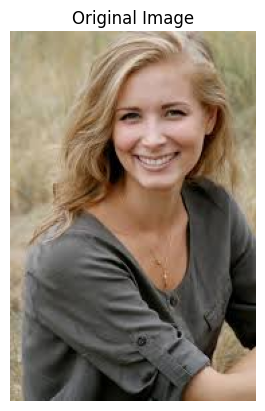

In [3]:
uploaded = files.upload()

filename = next(iter(uploaded))

img = cv2.imread(filename)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')
plt.show()

In [4]:
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('haarcascade_eye.xml')

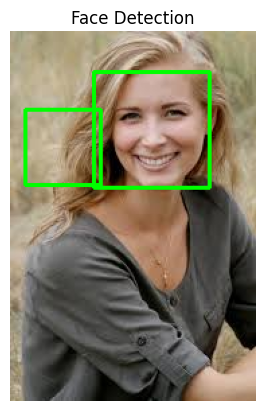

Faces Detected: 2


In [5]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30,30)
)

output = img.copy()

for (x,y,w,h) in faces:
    cv2.rectangle(output,(x,y),(x+w,y+h),(0,255,0),2)

output = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

plt.imshow(output)
plt.title("Face Detection")
plt.axis('off')
plt.show()

print("Faces Detected:", len(faces))

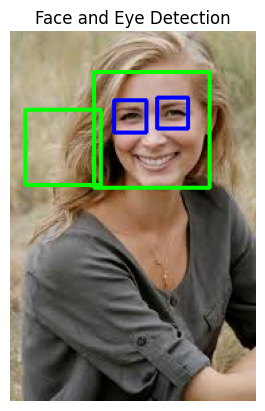

In [6]:
output = img.copy()

for (x,y,w,h) in faces:

    cv2.rectangle(output,(x,y),(x+w,y+h),(0,255,0),2)

    roi_gray = gray[y:y+h,x:x+w]
    roi_color = output[y:y+h,x:x+w]

    eyes = eye_cascade.detectMultiScale(roi_gray)

    for (ex,ey,ew,eh) in eyes:
        cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(255,0,0),2)

output = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

plt.imshow(output)
plt.title("Face and Eye Detection")
plt.axis('off')
plt.show()

Faces detected in Bright Image: 1


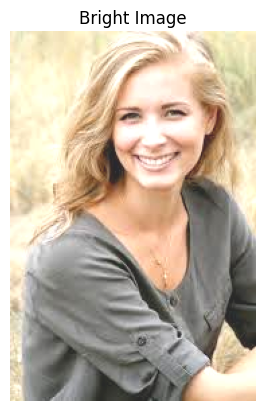

In [7]:
bright = cv2.convertScaleAbs(img, alpha=1.2, beta=40)

gray = cv2.cvtColor(bright, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(gray,1.1,5)

print("Faces detected in Bright Image:", len(faces))

bright_rgb = cv2.cvtColor(bright, cv2.COLOR_BGR2RGB)

plt.imshow(bright_rgb)
plt.title("Bright Image")
plt.axis('off')
plt.show()

Faces detected in Dark Image: 1


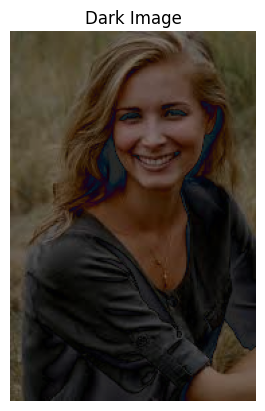

In [8]:
dark = cv2.convertScaleAbs(img, alpha=0.7, beta=-40)

gray = cv2.cvtColor(dark, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(gray,1.1,5)

print("Faces detected in Dark Image:", len(faces))

dark_rgb = cv2.cvtColor(dark, cv2.COLOR_BGR2RGB)

plt.imshow(dark_rgb)
plt.title("Dark Image")
plt.axis('off')
plt.show()

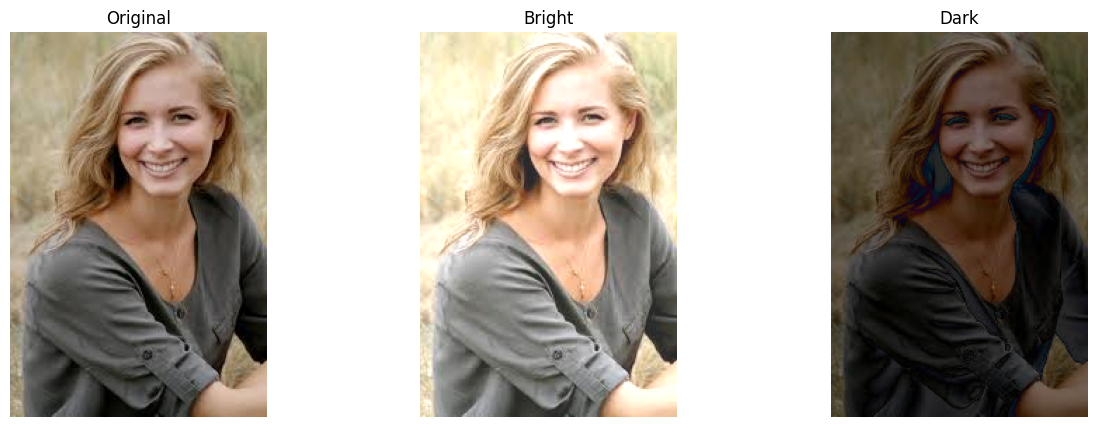

In [9]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(bright_rgb)
plt.title("Bright")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(dark_rgb)
plt.title("Dark")
plt.axis('off')

plt.show()